# 🟢 Project - Titanic Survival Rules (End-to-End)

> **MLCourse · Machine Learning · supervised · classification**

### Business question
Extract the survival RULEBOOK as human-readable IF/THEN logic from real
passenger records - one small decision tree, fully auditable.

End-to-end: load → EDA → processing → depth-3 training → rule extraction +
honest evaluation.

In [1]:
%matplotlib inline
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

ML_ROOT = Path.cwd()
while ML_ROOT.name != "02_machine_learning" and ML_ROOT != ML_ROOT.parent:
    ML_ROOT = ML_ROOT.parent

def get_data(fname, url):
    f = ML_ROOT / "data" / fname
    if not f.exists():
        f.write_bytes(urllib.request.urlopen(url).read())
        print("downloaded ->", fname)
    else:
        print("using local ->", fname)
    return pd.read_csv(f)

### 2. Data loading


In [2]:
df = get_data(
    "titanic.csv",
    "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv",
)
num_cols = [c for c in ["pclass", "age", "sibsp", "siblings_spouses_aboard",
                        "parch", "parents_children_aboard", "fare"] if c in df]
cat_cols = [c for c in ["sex", "embarked", "embark_town"] if c in df]
print("numeric:", num_cols, "| categorical:", cat_cols)

using local -> titanic.csv
numeric: ['pclass', 'age', 'sibsp', 'parch', 'fare'] | categorical: ['sex', 'embarked', 'embark_town']


### 3. Exploratory Data Analysis


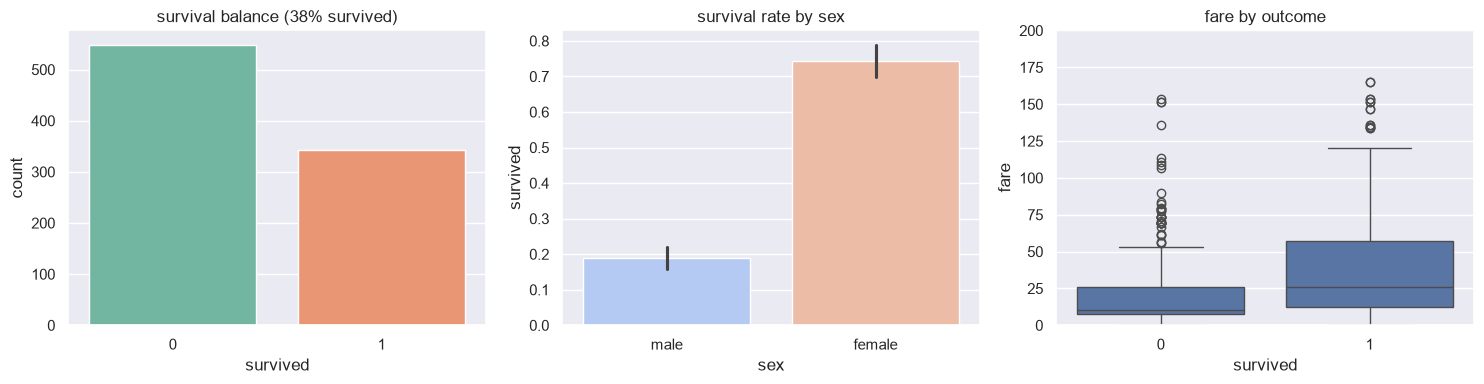

missing:
 pclass           0
age            177
sibsp            0
parch            0
fare             0
sex              0
embarked         2
embark_town      2
dtype: int64


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(x="survived", data=df, ax=axes[0],
              palette="Set2", hue="survived", legend=False)
axes[0].set_title(f"survival balance ({df.survived.mean():.0%} survived)")

if "sex" in cat_cols:
    sns.barplot(data=df, x="sex", y="survived", ax=axes[1],
                palette="coolwarm", hue="sex", legend=False)
    axes[1].set_title("survival rate by sex")

sns.boxplot(data=df, x="survived", y="fare", ax=axes[2])
axes[2].set_ylim(0, 200); axes[2].set_title("fare by outcome")
plt.tight_layout(); plt.show()

print("missing:\n", df[num_cols + cat_cols].isna().sum())

### 4. Data processing - impute → encode → split


In [4]:
work = df[num_cols + cat_cols + ["survived"]].copy()
for c in num_cols:
    if work[c].isna().any():
        work[c] = work[c].fillna(work[c].median())
for c in cat_cols:
    if work[c].isna().any():
        work[c] = work[c].fillna(work[c].mode()[0])

X = pd.get_dummies(work[cat_cols + num_cols], drop_first=True)
y = work["survived"].values

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=.25,
                                          random_state=42, stratify=y)

### 5. Model training - deliberately SMALL tree (depth 3)


In [5]:
tree_small = DecisionTreeClassifier(max_depth=3,        # readable on purpose
                                    min_samples_leaf=30,
                                    random_state=42).fit(X_tr, y_tr)
pred = tree_small.predict(X_te)
cv = cross_val_score(tree_small, X_tr, y_tr, cv=5).mean()

print(f"test accuracy {accuracy_score(y_te, pred):.4f} | CV {cv:.4f}")
display(pd.DataFrame(confusion_matrix(y_te, pred),
                     index=["true died", "true survived"],
                     columns=["pred died", "pred survived"]))

test accuracy 0.7803 | CV 0.8054


,pred died,pred survived
true died,131,6
true survived,43,43


### 5b. The rulebook - text & diagram


|--- sex_male <= 0.50
|   |--- pclass <= 2.50
|   |   |--- fare <= 28.86
|   |   |   |--- class: survived
|   |   |--- fare >  28.86
|   |   |   |--- class: survived
|   |--- pclass >  2.50
|   |   |--- fare <= 7.89
|   |   |   |--- class: survived
|   |   |--- fare >  7.89
|   |   |   |--- class: died
|--- sex_male >  0.50
|   |--- fare <= 26.27
|   |   |--- age <= 20.25
|   |   |   |--- class: died
|   |   |--- age >  20.25
|   |   |   |--- class: died
|   |--- fare >  26.27
|   |   |--- pclass <= 1.50
|   |   |   |--- class: died
|   |   |--- pclass >  1.50
|   |   |   |--- class: died



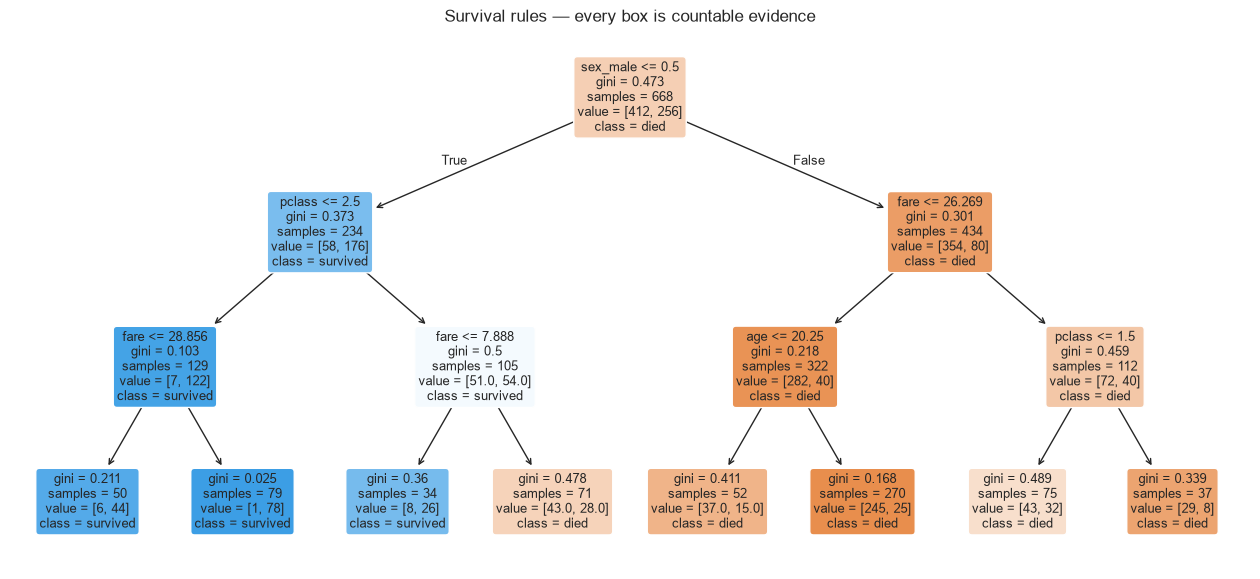

In [6]:
print(export_text(tree_small, feature_names=list(X.columns),
                  class_names=["died", "survived"]))

plt.figure(figsize=(16, 7))
plot_tree(tree_small, feature_names=X.columns,
          class_names=["died", "survived"], filled=True, rounded=True,
          fontsize=9)
plt.title("Survival rules - every box is countable evidence")
plt.show()

### 6. Findings

1. First question is always SEX; women ~74% vs men ~19% survival.
2. Within women, class ≤ 2 ≈ near-guarantee; within men only youth/fare help.
3. Depth-3 keeps ~79-81% accuracy while staying fully explainable.

### Takeaway
`export_text` turns a model into policy documentation stakeholders can quote.